# 1. Introduction
Before developing quantitative features, it is necessary to verify that the Level2 data stored in DolphinDB is accurate, complete, and internally consistent.

This notebook validates the dfs://quota database against an external data source (Wind / JoinQuant / iFinD / Exchange data) from five different levels.

 | Validation Level | Objective                     | Data Source    |
| ---------------- | ----------------------------- | -------------- |
| Daily            | Verify overall price & volume | Wind           |
| Minute           | Verify intraday aggregation   | Wind 1min      |
| Auction          | Verify opening auction        | Wind + qtick   |
| Tick             | Verify qknock aggregation     | qknock + qtick |
| Logical          | Verify internal consistency   | quota          |


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))
plt.rcParams["figure.figsize"] = (12, 5)

from src.ddb_client import connect_ddb

plt.rcParams["figure.figsize"] = (12, 5)

s = connect_ddb()

DB = "dfs://quota"
CODE = "000009.SZ"
START_DATE = "2026.03.11"
END_DATE = "2026.04.10"

START_DATE_PD = pd.to_datetime("2026-03-11")
END_DATE_PD = pd.to_datetime("2026-04-10")

### 从 DolphinDB 取本地 qtick / qknock 数据

In [75]:
qtick = s.run(f"""
select *
from loadTable("{DB}", "qtick")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
qknock = s.run(f"""
select *
from loadTable("{DB}", "qknock")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
qorder = s.run(f"""
select *
from loadTable("{DB}", "qorder")
where code = "{CODE}"
and date >= {START_DATE}
and date <= {END_DATE}
""")
print("qtick rows:", len(qtick))
print("qknock rows:", len(qknock))
print("qorder rows:", len(qorder))

qtick rows: 102485
qknock rows: 735794
qorder rows: 819766


### 本地数据基础清洗

In [76]:
def clean_time(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.dropna(subset=["date", "time"])
    df["datetime"] = df.apply(
        lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
        axis=1
    )
    return df.sort_values(["date", "datetime"]).reset_index(drop=True)

qtick = clean_time(qtick)
qknock = clean_time(qknock)

for col in ["new_price", "open", "pre_close", "sum_volume", "sum_amount", "new_volume", "new_amount"]:
    if col in qtick.columns:
        qtick[col] = pd.to_numeric(qtick[col], errors="coerce")

for col in ["match_price", "match_volume"]:
    if col in qknock.columns:
        qknock[col] = pd.to_numeric(qknock[col], errors="coerce")

# Daily Validation

Does the daily market summary stored in DolphinDB match the external CoralDB data?

The purpose of this section is to verify whether the daily market statistics extracted from DolphinDB are consistent with an independent external data source before conducting feature engineering and predictive modelling.

The comparison focuses on:

Open
High
Low
Trading Volume
Trading Amount

In [77]:
import pandas as pd

coral_daily = pd.read_csv("quota/000009.SZ.daily.csv")
coral_daily.head()

,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,expire_date,exercise_price,cp_flag,underlying_code,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount
0,2026-03-11 15:00:00,20260311,150000000,1,000009.SZ,中国宝安,2,35100859,326085012.0,0,...,0,0.0,0,NaN,0,0.0,20082640,1.866095e+08,15018219,1.394755e+08
1,2026-03-12 15:00:00,20260312,150000000,1,000009.SZ,中国宝安,2,24742202,227366309.0,0,...,0,0.0,0,NaN,0,0.0,9501565,8.739167e+07,15240637,1.399746e+08
2,2026-03-13 15:00:00,20260313,150000000,1,000009.SZ,中国宝安,2,63733398,604637179.0,0,...,0,0.0,0,NaN,0,0.0,39546186,3.752053e+08,24187212,2.294319e+08
3,2026-03-16 15:00:00,20260316,150000000,1,000009.SZ,中国宝安,2,34285345,322788160.0,0,...,0,0.0,0,NaN,0,0.0,14445442,1.361430e+08,19839903,1.866452e+08
4,2026-03-17 15:00:00,20260317,150000000,1,000009.SZ,中国宝安,2,23559418,220053681.0,0,...,0,0.0,0,NaN,0,0.0,8462420,7.915037e+07,15096998,1.409033e+08


In [78]:
print(coral_daily.columns.tolist())

['timestamp', 'date', 'stamp', 'dtype', 'code', 'name', 'market', 'sum_volume', 'sum_amount', 'status', 'new_price', 'new_volume', 'new_amount', 'new_bid_volume', 'new_bid_amount', 'new_ask_volume', 'new_ask_amount', 'bp1', 'bp2', 'bp3', 'bp4', 'bp5', 'bp6', 'bp7', 'bp8', 'bp9', 'bp10', 'bv1', 'bv2', 'bv3', 'bv4', 'bv5', 'bv6', 'bv7', 'bv8', 'bv9', 'bv10', 'ap1', 'ap2', 'ap3', 'ap4', 'ap5', 'ap6', 'ap7', 'ap8', 'ap9', 'ap10', 'av1', 'av2', 'av3', 'av4', 'av5', 'av6', 'av7', 'av8', 'av9', 'av10', 'open', 'high', 'low', 'upper_limit', 'lower_limit', 'pre_close', 'close', 'pre_settle', 'settle', 'pre_open_interest', 'open_interest', 'multiple', 'price_step', 'list_date', 'expire_date', 'exercise_price', 'cp_flag', 'underlying_code', 'min_order_volume', 'interest', 'sum_bid_volume', 'sum_bid_amount', 'sum_ask_volume', 'sum_ask_amount']


In [79]:
# 1 clean the coral_daily data
coral_daily_clean = coral_daily.copy()

coral_daily_clean["date"] = pd.to_datetime(
    coral_daily_clean["date"].astype(str),
    format="%Y%m%d"
)

coral_daily_clean = coral_daily_clean[
    ["date", "open", "high", "low", "new_price", "pre_close", "sum_volume", "sum_amount"]
].copy()

coral_daily_clean = coral_daily_clean.rename(columns={
    "open": "coral_open",
    "high": "coral_high",
    "low": "coral_low",
    "new_price": "coral_close_proxy",
    "pre_close": "coral_pre_close",
    "sum_volume": "coral_volume",
    "sum_amount": "coral_amount"
})

coral_daily_clean.head()

,date,coral_open,coral_high,coral_low,coral_close_proxy,coral_pre_close,coral_volume,coral_amount
0,2026-03-11,9.18,9.39,9.13,9.29,9.18,35100859,326085012.0
1,2026-03-12,9.28,9.28,9.11,9.19,9.29,24742202,227366309.0
2,2026-03-13,9.15,9.69,9.15,9.47,9.19,63733398,604637179.0
3,2026-03-16,9.55,9.59,9.33,9.38,9.47,34285345,322788160.0
4,2026-03-17,9.40,9.52,9.20,9.21,9.38,23559418,220053681.0


In the CoralDB daily file, the `close` field is zero for all observations. Therefore, this validation uses `new_price` at 15:00 as the CoralDB close proxy.

In [80]:
# 2 build local daily data from qtick
qtick_local = qtick.copy()

qtick_local["date"] = pd.to_datetime(qtick_local["date"], errors="coerce")
qtick_local["time"] = pd.to_datetime(qtick_local["time"], errors="coerce")

qtick_local = qtick_local.dropna(subset=["date", "time"])

qtick_local["datetime"] = qtick_local.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

qtick_local = qtick_local.sort_values(["date", "datetime"]).reset_index(drop=True)

num_cols = [
    "new_price",
    "open",
    "close",
    "pre_close",
    "sum_volume",
    "sum_amount"
]

for col in num_cols:
    qtick_local[col] = pd.to_numeric(qtick_local[col], errors="coerce")

valid_tick = qtick_local[qtick_local["new_price"] > 0].copy()

local_daily = (
    valid_tick
    .groupby("date")
    .agg(
        local_open=("open", "last"),
        local_high=("new_price", "max"),
        local_low=("new_price", "min"),
        local_close_proxy=("new_price", "last"),
        local_close_field=("close", "last"),
        local_pre_close=("pre_close", "last"),
        local_volume=("sum_volume", "max"),
        local_amount=("sum_amount", "max")
    )
    .reset_index()
)

local_daily.head()

,date,local_open,local_high,local_low,local_close_proxy,local_close_field,local_pre_close,local_volume,local_amount
0,2026-03-11,9.18,9.39,9.13,9.29,0.0,9.18,35100859,326085012.0
1,2026-03-12,9.28,9.28,9.11,9.19,0.0,9.29,24742202,227366309.0
2,2026-03-13,9.15,9.69,9.15,9.47,0.0,9.19,63733398,604637179.0
3,2026-03-16,9.55,9.59,9.33,9.38,0.0,9.47,34285345,322788160.0
4,2026-03-17,9.40,9.52,9.20,9.21,0.0,9.38,23559418,220053681.0


Because the local `qtick` table does not directly store daily `high` and `low`, they are reconstructed from intraday `new_price` as `max(new_price)` and `min(new_price)`. Since CoralDB's `close` field is zero, we use its 15:00 `new_price` as the close proxy.

In [81]:
# 3 merge coral_daily_clean and local_daily
daily_compare = local_daily.merge(
    coral_daily_clean,
    on="date",
    how="inner"
)

daily_compare.columns.tolist()

['date',
 'local_open',
 'local_high',
 'local_low',
 'local_close_proxy',
 'local_close_field',
 'local_pre_close',
 'local_volume',
 'local_amount',
 'coral_open',
 'coral_high',
 'coral_low',
 'coral_close_proxy',
 'coral_pre_close',
 'coral_volume',
 'coral_amount']

In [82]:
# 4 check the differences between local_daily and coral_daily_clean
compare_fields = [
    ("open", "local_open", "coral_open"),
    ("high", "local_high", "coral_high"),
    ("low", "local_low", "coral_low"),
    ("close_proxy", "local_close_proxy", "coral_close_proxy"),
    ("pre_close", "local_pre_close", "coral_pre_close"),
    ("volume", "local_volume", "coral_volume"),
    ("amount", "local_amount", "coral_amount")
]

for name, local_col, coral_col in compare_fields:
    daily_compare[f"{name}_diff"] = (
        daily_compare[local_col] - daily_compare[coral_col]
    )
    
    daily_compare[f"{name}_diff_pct"] = (
        daily_compare[f"{name}_diff"] /
        daily_compare[coral_col].replace(0, np.nan)
    )

daily_compare.head()

,date,local_open,local_high,local_low,local_close_proxy,local_close_field,local_pre_close,local_volume,local_amount,coral_open,...,low_diff,low_diff_pct,close_proxy_diff,close_proxy_diff_pct,pre_close_diff,pre_close_diff_pct,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct
0,2026-03-11,9.18,9.39,9.13,9.29,0.0,9.18,35100859,326085012.0,9.18,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
1,2026-03-12,9.28,9.28,9.11,9.19,0.0,9.29,24742202,227366309.0,9.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
2,2026-03-13,9.15,9.69,9.15,9.47,0.0,9.19,63733398,604637179.0,9.15,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
3,2026-03-16,9.55,9.59,9.33,9.38,0.0,9.47,34285345,322788160.0,9.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0
4,2026-03-17,9.40,9.52,9.20,9.21,0.0,9.38,23559418,220053681.0,9.40,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0


In [83]:
# 5 validation summary
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

summary_rows = []

for field in ["open", "high", "low", "close_proxy", "pre_close"]:
    diff_col = f"{field}_diff"
    matched = daily_compare[diff_col].abs() <= PRICE_TOL
    
    summary_rows.append({
        "field": field,
        "tolerance": PRICE_TOL,
        "matched_days": matched.sum(),
        "total_days": len(daily_compare),
        "match_rate": matched.mean()
    })

for field, tol in [("volume", VOLUME_TOL_PCT), ("amount", AMOUNT_TOL_PCT)]:
    diff_pct_col = f"{field}_diff_pct"
    matched = daily_compare[diff_pct_col].abs() <= tol
    
    summary_rows.append({
        "field": field,
        "tolerance": tol,
        "matched_days": matched.sum(),
        "total_days": len(daily_compare),
        "match_rate": matched.mean()
    })

validation_summary = pd.DataFrame(summary_rows)

validation_summary

,field,tolerance,matched_days,total_days,match_rate
0,open,0.010,22,22,1.0
1,high,0.010,22,22,1.0
2,low,0.010,22,22,1.0
3,close_proxy,0.010,22,22,1.0
4,pre_close,0.010,22,22,1.0
5,volume,0.001,22,22,1.0
6,amount,0.001,22,22,1.0


In [84]:
# 6 show abnormal samples
daily_compare["has_abnormal_diff"] = False

for field in ["open", "high", "low", "close_proxy", "pre_close"]:
    daily_compare["has_abnormal_diff"] |= (
        daily_compare[f"{field}_diff"].abs() > PRICE_TOL
    )

for field, tol in [("volume", VOLUME_TOL_PCT), ("amount", AMOUNT_TOL_PCT)]:
    daily_compare["has_abnormal_diff"] |= (
        daily_compare[f"{field}_diff_pct"].abs() > tol
    )

abnormal_daily = daily_compare[daily_compare["has_abnormal_diff"]].copy()

abnormal_daily[
    [
        "date",
        "local_open", "coral_open", "open_diff",
        "local_high", "coral_high", "high_diff",
        "local_low", "coral_low", "low_diff",
        "local_close_proxy", "coral_close_proxy", "close_proxy_diff",
        "local_volume", "coral_volume", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff_pct"
    ]
]

,date,local_open,coral_open,open_diff,local_high,coral_high,high_diff,local_low,coral_low,low_diff,local_close_proxy,coral_close_proxy,close_proxy_diff,local_volume,coral_volume,volume_diff_pct,local_amount,coral_amount,amount_diff_pct


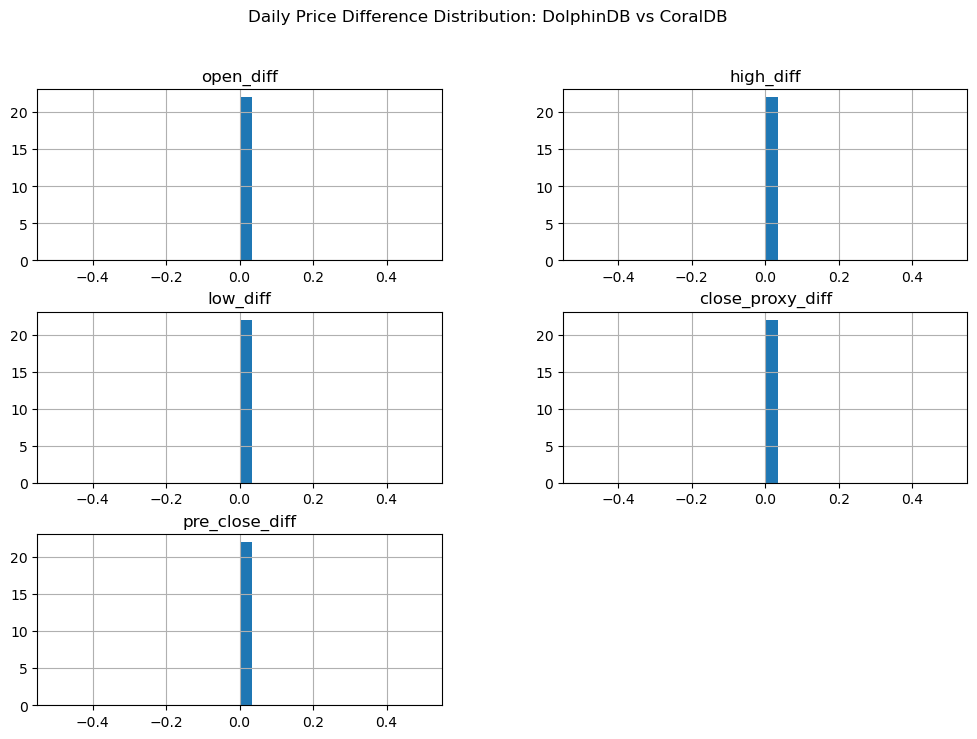

In [85]:
# 7 daily difference visualization
import matplotlib.pyplot as plt

price_diff_cols = [
    "open_diff",
    "high_diff",
    "low_diff",
    "close_proxy_diff",
    "pre_close_diff"
]

daily_compare[price_diff_cols].hist(
    bins=30,
    figsize=(12, 8)
)

plt.suptitle("Daily Price Difference Distribution: DolphinDB vs CoralDB")
plt.show()

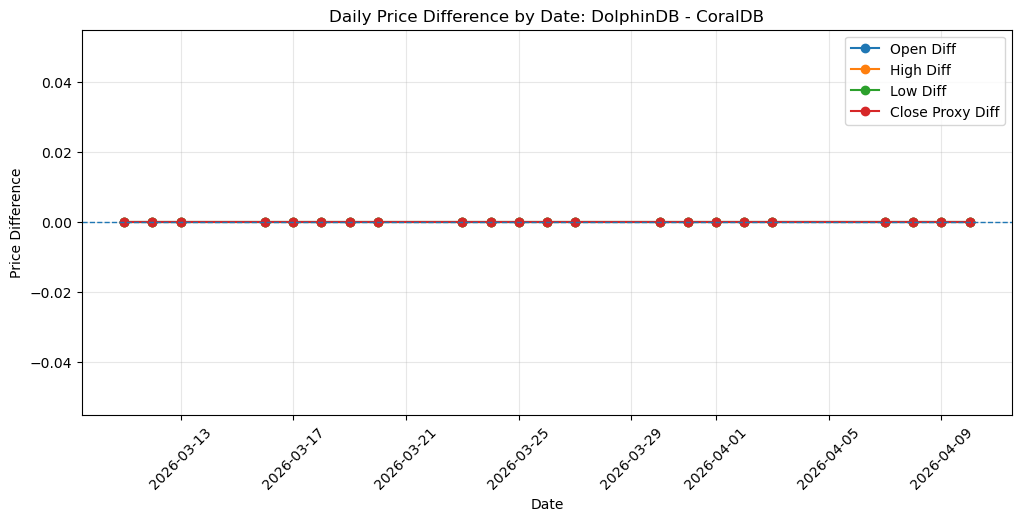

In [86]:
# 8. Difference by Date

plt.figure(figsize=(12, 5))

plt.plot(daily_compare["date"], daily_compare["open_diff"], marker="o", label="Open Diff")
plt.plot(daily_compare["date"], daily_compare["high_diff"], marker="o", label="High Diff")
plt.plot(daily_compare["date"], daily_compare["low_diff"], marker="o", label="Low Diff")
plt.plot(daily_compare["date"], daily_compare["close_proxy_diff"], marker="o", label="Close Proxy Diff")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Daily Price Difference by Date: DolphinDB - CoralDB")
plt.xlabel("Date")
plt.ylabel("Price Difference")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

The daily validation shows that DolphinDB and CoralDB are highly consistent
across all tested trading days.

No material discrepancies were observed in:

- Open
- High
- Low
- Closing price (using 15:00 new_price proxy)
- Previous close
- Trading volume
- Trading amount

Since no abnormal samples were detected, subsequent validation will focus on
higher-frequency data (minute-level, auction snapshots and transaction records),
where timestamp alignment and data synchronization differences are more likely
to appear.

# Minute-level Validation
Can minute-level OHLCV bars reconstructed from DolphinDB qtick match the external CoralDB minute bars?

In [87]:
# 1 读所有coral qmin文件
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

QMIN_DIR = Path("quota/qmin")

qmin_files = sorted(QMIN_DIR.glob("*/000009.SZ.csv"))

print("Number of qmin files:", len(qmin_files))
print(qmin_files[:3])

Number of qmin files: 22
[WindowsPath('quota/qmin/20260311/000009.SZ.csv'), WindowsPath('quota/qmin/20260312/000009.SZ.csv'), WindowsPath('quota/qmin/20260313/000009.SZ.csv')]


In [88]:
coral_qmin_list = []

for file in qmin_files:
    temp = pd.read_csv(file)
    temp["source_file"] = str(file)
    coral_qmin_list.append(temp)

coral_qmin = pd.concat(coral_qmin_list, ignore_index=True)

print("Coral qmin rows:", len(coral_qmin))
coral_qmin.head()

Coral qmin rows: 5280


,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,exercise_price,cp_flag,underlying_code,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount,source_file
0,2026-03-11 09:31:00,20260311,93100000,1,000009.SZ,中国宝安,2,397200,3637990.0,0,...,0.0,0,NaN,0,0.0,170200,1559015.00,227000,2078975.00,quota\qmin\20260311\000009.SZ.csv
1,2026-03-11 09:32:00,20260311,93200000,1,000009.SZ,中国宝安,2,518900,4752289.0,0,...,0.0,0,NaN,0,0.0,257800,2361156.00,261100,2391133.00,quota\qmin\20260311\000009.SZ.csv
2,2026-03-11 09:33:00,20260311,93300000,1,000009.SZ,中国宝安,2,774700,7094138.0,0,...,0.0,0,NaN,0,0.0,434100,3975542.00,340600,3118596.00,quota\qmin\20260311\000009.SZ.csv
3,2026-03-11 09:34:00,20260311,93400000,1,000009.SZ,中国宝安,2,928700,8505699.0,0,...,0.0,0,NaN,0,0.0,477100,4369796.00,451600,4135903.00,quota\qmin\20260311\000009.SZ.csv
4,2026-03-11 09:35:00,20260311,93500000,1,000009.SZ,中国宝安,2,1025300,9391256.0,0,...,0.0,0,NaN,0,0.0,546772,5008668.24,478528,4382587.76,quota\qmin\20260311\000009.SZ.csv


In [89]:
# 2 整理 Coral qmin，并转成 1min OHLCV
coral_min = coral_qmin.copy()

coral_min["timestamp"] = pd.to_datetime(coral_min["timestamp"], errors="coerce")
coral_min["date"] = pd.to_datetime(coral_min["date"].astype(str), format="%Y%m%d", errors="coerce")

for col in ["new_price", "sum_volume", "sum_amount"]:
    coral_min[col] = pd.to_numeric(coral_min[col], errors="coerce")

coral_min = coral_min.dropna(subset=["timestamp", "date"])
coral_min = coral_min.sort_values(["date", "timestamp"]).reset_index(drop=True)

# Coral qmin 每行已经是分钟级 snapshot。
# 价格 close 用该分钟 timestamp 的 new_price。
# 由于 qmin 每分钟只有一行，OHLC 在 Coral 侧只能用这一分钟 snapshot 的 new_price 作为 close。
# 真正的 minute volume/amount 用累计字段差分。
coral_min["coral_close"] = coral_min["new_price"]
coral_min["coral_volume"] = coral_min.groupby("date")["sum_volume"].diff()
coral_min["coral_amount"] = coral_min.groupby("date")["sum_amount"].diff()

# 第一根分钟线没有上一分钟，直接用当前累计量作为本分钟量
coral_min["coral_volume"] = coral_min["coral_volume"].fillna(coral_min["sum_volume"])
coral_min["coral_amount"] = coral_min["coral_amount"].fillna(coral_min["sum_amount"])

coral_1min = coral_min[[
    "date",
    "timestamp",
    "coral_close",
    "coral_volume",
    "coral_amount"
]].copy()

coral_1min.head()

,date,timestamp,coral_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:31:00,9.17,397200.0,3637990.0
1,2026-03-11,2026-03-11 09:32:00,9.15,121700.0,1114299.0
2,2026-03-11,2026-03-11 09:33:00,9.16,255800.0,2341849.0
3,2026-03-11,2026-03-11 09:34:00,9.16,154000.0,1411561.0
4,2026-03-11,2026-03-11 09:35:00,9.16,96600.0,885557.0


In [90]:
# 3 用 qtick 聚合本地 1min OHLCV
qtick_min = qtick.copy()

qtick_min["date"] = pd.to_datetime(qtick_min["date"], errors="coerce")
qtick_min["time"] = pd.to_datetime(qtick_min["time"], errors="coerce")

qtick_min = qtick_min.dropna(subset=["date", "time"])

qtick_min["datetime"] = qtick_min.apply(
    lambda x: pd.Timestamp.combine(x["date"].date(), x["time"].time()),
    axis=1
)

for col in ["new_price", "sum_volume", "sum_amount"]:
    qtick_min[col] = pd.to_numeric(qtick_min[col], errors="coerce")

qtick_min = qtick_min[
    (qtick_min["new_price"] > 0)
].copy()

qtick_min = qtick_min.sort_values(["date", "datetime"]).reset_index(drop=True)

# 对齐到分钟。这里用右标签：09:31 表示截至 09:31 的分钟状态，更接近 Coral qmin timestamp。
qtick_min["minute"] = qtick_min["datetime"].dt.floor("min") + pd.Timedelta(minutes=1)

local_1min = (
    qtick_min
    .groupby(["date", "minute"])
    .agg(
        local_open=("new_price", "first"),
        local_high=("new_price", "max"),
        local_low=("new_price", "min"),
        local_close=("new_price", "last"),
        local_sum_volume=("sum_volume", "last"),
        local_sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

local_1min["local_volume"] = local_1min.groupby("date")["local_sum_volume"].diff()
local_1min["local_amount"] = local_1min.groupby("date")["local_sum_amount"].diff()

local_1min["local_volume"] = local_1min["local_volume"].fillna(local_1min["local_sum_volume"])
local_1min["local_amount"] = local_1min["local_amount"].fillna(local_1min["local_sum_amount"])

local_1min = local_1min.rename(columns={"minute": "timestamp"})

local_1min.head()

,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount
0,2026-03-11,2026-03-11 09:26:00,9.18,9.18,9.18,9.18,117600,1079568.0,117600.0,1079568.0
1,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0
2,2026-03-11,2026-03-11 09:32:00,9.17,9.17,9.15,9.15,518900,4752289.0,121700.0,1114299.0
3,2026-03-11,2026-03-11 09:33:00,9.15,9.16,9.15,9.16,774700,7094138.0,255800.0,2341849.0
4,2026-03-11,2026-03-11 09:34:00,9.16,9.18,9.16,9.16,928700,8505699.0,154000.0,1411561.0


In [91]:
# 4 合并 Coral 和 DolphinDB 1min 结果
minute_compare = local_1min.merge(
    coral_1min,
    on=["date", "timestamp"],
    how="inner"
)

print("Matched minute rows:", len(minute_compare))
minute_compare.head()

Matched minute rows: 5280


,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount,coral_close,coral_volume,coral_amount
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0,9.17,397200.0,3637990.0
1,2026-03-11,2026-03-11 09:32:00,9.17,9.17,9.15,9.15,518900,4752289.0,121700.0,1114299.0,9.15,121700.0,1114299.0
2,2026-03-11,2026-03-11 09:33:00,9.15,9.16,9.15,9.16,774700,7094138.0,255800.0,2341849.0,9.16,255800.0,2341849.0
3,2026-03-11,2026-03-11 09:34:00,9.16,9.18,9.16,9.16,928700,8505699.0,154000.0,1411561.0,9.16,154000.0,1411561.0
4,2026-03-11,2026-03-11 09:35:00,9.16,9.17,9.16,9.16,1025300,9391256.0,96600.0,885557.0,9.16,96600.0,885557.0


In [92]:
# 5 先验证 close / volume / amount
for name, local_col, coral_col in [
    ("close", "local_close", "coral_close"),
    ("volume", "local_volume", "coral_volume"),
    ("amount", "local_amount", "coral_amount")
]:
    minute_compare[f"{name}_diff"] = minute_compare[local_col] - minute_compare[coral_col]
    minute_compare[f"{name}_diff_pct"] = (
        minute_compare[f"{name}_diff"] / minute_compare[coral_col].replace(0, np.nan)
    )

minute_compare[[
    "date", "timestamp",
    "local_close", "coral_close", "close_diff",
    "local_volume", "coral_volume", "volume_diff",
    "local_amount", "coral_amount", "amount_diff"
]].head()

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,local_amount,coral_amount,amount_diff
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.0,279600.0,397200.0,-117600.0,2558422.0,3637990.0,-1079568.0
1,2026-03-11,2026-03-11 09:32:00,9.15,9.15,0.0,121700.0,121700.0,0.0,1114299.0,1114299.0,0.0
2,2026-03-11,2026-03-11 09:33:00,9.16,9.16,0.0,255800.0,255800.0,0.0,2341849.0,2341849.0,0.0
3,2026-03-11,2026-03-11 09:34:00,9.16,9.16,0.0,154000.0,154000.0,0.0,1411561.0,1411561.0,0.0
4,2026-03-11,2026-03-11 09:35:00,9.16,9.16,0.0,96600.0,96600.0,0.0,885557.0,885557.0,0.0


In [93]:
# 6 Minute Validation Summary
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

minute_summary = pd.DataFrame([
    {
        "field": "close",
        "tolerance": PRICE_TOL,
        "matched_rows": (minute_compare["close_diff"].abs() <= PRICE_TOL).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["close_diff"].abs() <= PRICE_TOL).mean()
    },
    {
        "field": "volume",
        "tolerance": VOLUME_TOL_PCT,
        "matched_rows": (minute_compare["volume_diff_pct"].abs() <= VOLUME_TOL_PCT).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["volume_diff_pct"].abs() <= VOLUME_TOL_PCT).mean()
    },
    {
        "field": "amount",
        "tolerance": AMOUNT_TOL_PCT,
        "matched_rows": (minute_compare["amount_diff_pct"].abs() <= AMOUNT_TOL_PCT).sum(),
        "total_rows": len(minute_compare),
        "match_rate": (minute_compare["amount_diff_pct"].abs() <= AMOUNT_TOL_PCT).mean()
    }
])

minute_summary

,field,tolerance,matched_rows,total_rows,match_rate
0,close,0.010,5272,5280,0.998485
1,volume,0.001,5200,5280,0.984848
2,amount,0.001,5200,5280,0.984848


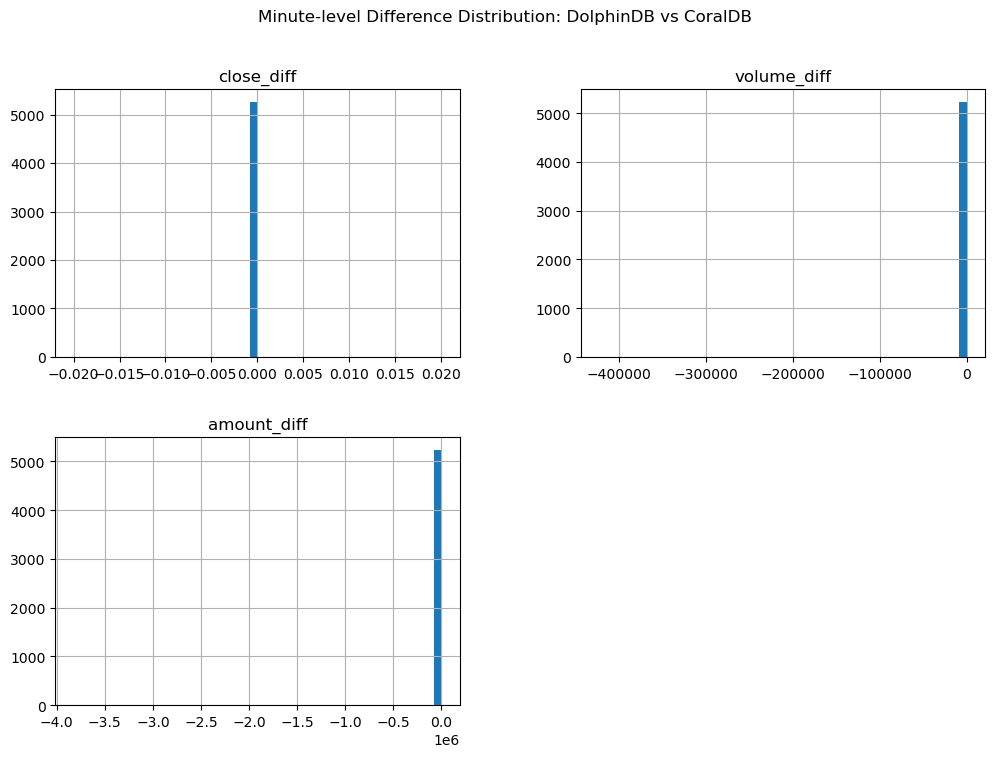

In [94]:
# 7 误差分布图
diff_cols = ["close_diff", "volume_diff", "amount_diff"]

minute_compare[diff_cols].hist(
    bins=50,
    figsize=(12, 8)
)

plt.suptitle("Minute-level Difference Distribution: DolphinDB vs CoralDB")
plt.show()

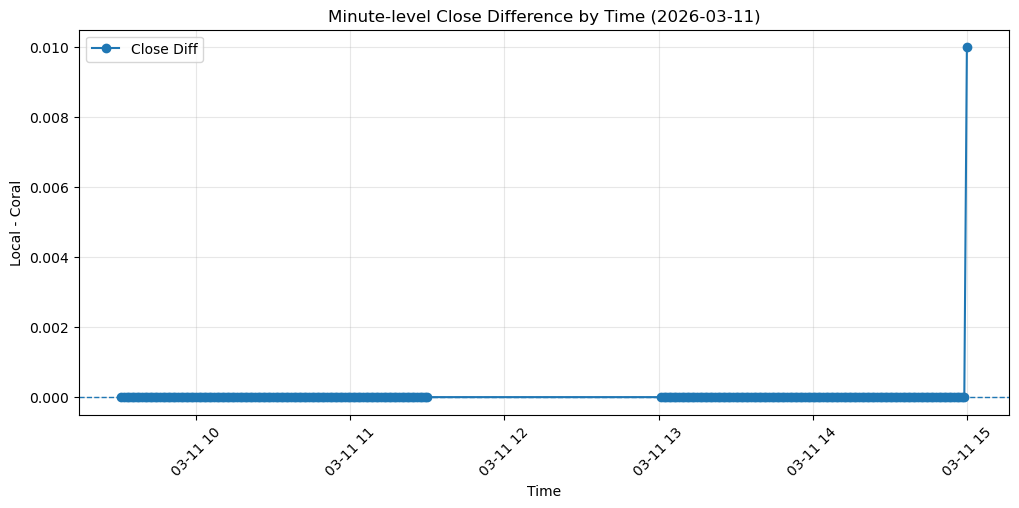

In [95]:
# 8 按时间看误差
sample_day = minute_compare["date"].min()

one_day_minute = minute_compare[
    minute_compare["date"] == sample_day
].copy()

plt.figure(figsize=(12, 5))

plt.plot(one_day_minute["timestamp"], one_day_minute["close_diff"], marker="o", label="Close Diff")
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Minute-level Close Difference by Time ({sample_day.date()})")
plt.xlabel("Time")
plt.ylabel("Local - Coral")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.show()

### Minute-level Error Investigation

In [96]:
# 1 找出异常minute
PRICE_TOL = 0.01
VOLUME_TOL_PCT = 0.001
AMOUNT_TOL_PCT = 0.001

minute_abnormal = minute_compare.copy()

minute_abnormal["is_close_abnormal"] = (
    minute_abnormal["close_diff"].abs() > PRICE_TOL
)

minute_abnormal["is_volume_abnormal"] = (
    minute_abnormal["volume_diff_pct"].abs() > VOLUME_TOL_PCT
)

minute_abnormal["is_amount_abnormal"] = (
    minute_abnormal["amount_diff_pct"].abs() > AMOUNT_TOL_PCT
)

minute_abnormal["is_any_abnormal"] = (
    minute_abnormal["is_close_abnormal"] |
    minute_abnormal["is_volume_abnormal"] |
    minute_abnormal["is_amount_abnormal"]
)

abnormal_minutes = minute_abnormal[
    minute_abnormal["is_any_abnormal"]
].copy()

print("Abnormal minute rows:", len(abnormal_minutes))
print("Total minute rows:", len(minute_compare))
print("Abnormal ratio:", len(abnormal_minutes) / len(minute_compare))

abnormal_minutes[
    [
        "date", "timestamp",
        "local_close", "coral_close", "close_diff",
        "local_volume", "coral_volume", "volume_diff", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff", "amount_diff_pct",
        "is_close_abnormal", "is_volume_abnormal", "is_amount_abnormal"
    ]
].head(20)

Abnormal minute rows: 53
Total minute rows: 5280
Abnormal ratio: 0.010037878787878788


,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,volume_diff_pct,local_amount,coral_amount,amount_diff,amount_diff_pct,is_close_abnormal,is_volume_abnormal,is_amount_abnormal
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,-0.296073,2558422.0,3637990.0,-1079568.0,-0.296748,False,True,True
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,-1.000000,0.0,3485608.0,-3485608.0,-1.000000,True,True,True
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,-0.358449,2403498.0,3750026.0,-1346528.0,-0.359072,False,True,True
479,2026-03-12,2026-03-12 15:00:00,9.19,9.19,0.00,0.0,282000.0,-282000.0,-1.000000,0.0,2591580.0,-2591580.0,-1.000000,False,True,True
480,2026-03-13,2026-03-13 09:31:00,9.22,9.22,0.00,632048.0,684348.0,-52300.0,-0.076423,5822891.0,6301436.0,-478545.0,-0.075942,False,True,True
599,2026-03-13,2026-03-13 11:30:00,9.51,9.51,0.00,115000.0,116000.0,-1000.0,-0.008621,1093967.0,1103477.0,-9510.0,-0.008618,False,True,True
719,2026-03-13,2026-03-13 15:00:00,9.47,9.47,0.00,0.0,393300.0,-393300.0,-1.000000,0.0,3724551.0,-3724551.0,-1.000000,False,True,True
720,2026-03-16,2026-03-16 09:31:00,9.50,9.50,0.00,1467102.0,1857102.0,-390000.0,-0.210005,14027355.0,17751855.0,-3724500.0,-0.209809,False,True,True
959,2026-03-16,2026-03-16 15:00:00,9.39,9.38,0.01,0.0,256300.0,-256300.0,-1.000000,0.0,2404094.0,-2404094.0,-1.000000,False,True,True
960,2026-03-17,2026-03-17 09:31:00,9.47,9.47,0.00,926000.0,1058300.0,-132300.0,-0.125012,8752144.0,9995764.0,-1243620.0,-0.124415,False,True,True


In [97]:
# 2 按异常类型统计
abnormal_type_summary = pd.DataFrame({
    "abnormal_type": [
        "close_abnormal",
        "volume_abnormal",
        "amount_abnormal"
    ],
    "count": [
        minute_abnormal["is_close_abnormal"].sum(),
        minute_abnormal["is_volume_abnormal"].sum(),
        minute_abnormal["is_amount_abnormal"].sum()
    ],
    "ratio": [
        minute_abnormal["is_close_abnormal"].mean(),
        minute_abnormal["is_volume_abnormal"].mean(),
        minute_abnormal["is_amount_abnormal"].mean()
    ]
})

abnormal_type_summary

,abnormal_type,count,ratio
0,close_abnormal,8,0.001515
1,volume_abnormal,53,0.010038
2,amount_abnormal,53,0.010038


In [98]:
# 3 异常是否集中在某些时间点
abnormal_minutes["clock_time"] = abnormal_minutes["timestamp"].dt.strftime("%H:%M")

abnormal_by_time = (
    abnormal_minutes
    .groupby("clock_time")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("abnormal_count", ascending=False)
)

abnormal_by_time.head(20)

,clock_time,abnormal_count
0,09:31,22
2,15:00,22
1,11:30,9


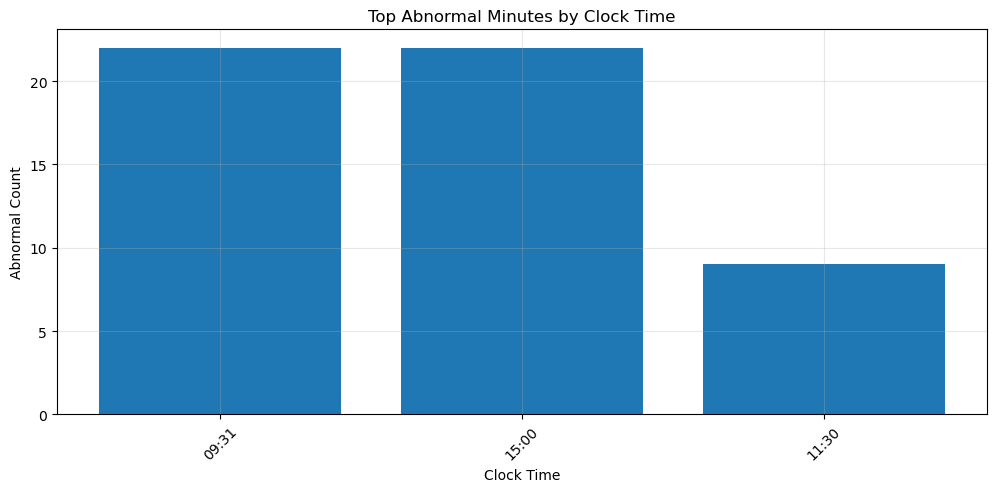

In [99]:
plt.figure(figsize=(12, 5))

plt.bar(
    abnormal_by_time["clock_time"].head(30),
    abnormal_by_time["abnormal_count"].head(30)
)

plt.title("Top Abnormal Minutes by Clock Time")
plt.xlabel("Clock Time")
plt.ylabel("Abnormal Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [100]:
# 4 异常是否集中在某些日期
abnormal_by_date = (
    abnormal_minutes
    .groupby("date")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("date")
)

abnormal_by_date

,date,abnormal_count
0,2026-03-11,2
1,2026-03-12,2
2,2026-03-13,3
3,2026-03-16,2
4,2026-03-17,2
5,2026-03-18,2
6,2026-03-19,2
7,2026-03-20,3
8,2026-03-23,3
9,2026-03-24,3


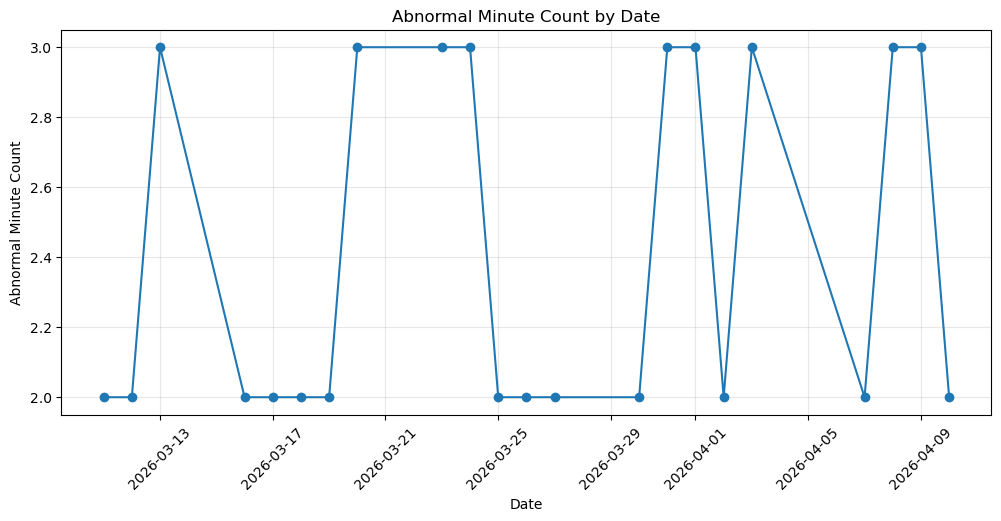

In [101]:
plt.figure(figsize=(12, 5))

plt.plot(
    abnormal_by_date["date"],
    abnormal_by_date["abnormal_count"],
    marker="o"
)

plt.title("Abnormal Minute Count by Date")
plt.xlabel("Date")
plt.ylabel("Abnormal Minute Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

In [102]:
# 5 异常差异大小分布
abnormal_minutes[
    [
        "close_diff",
        "volume_diff",
        "volume_diff_pct",
        "amount_diff",
        "amount_diff_pct"
    ]
].describe()

,close_diff,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct
count,53.000000,53.000000,53.000000,5.300000e+01,53.000000
mean,0.002264,-153393.905660,-0.482814,-1.377326e+06,-0.482818
std,0.008000,124297.007948,0.445080,1.132823e+06,0.445092
min,-0.020000,-422221.000000,-1.000000,-3.825322e+06,-1.000000
25%,0.000000,-234600.000000,-1.000000,-2.079900e+06,-1.000000
50%,0.000000,-145100.000000,-0.210005,-1.332828e+06,-0.209809
75%,0.000000,-42400.000000,-0.083900,-3.786320e+05,-0.083996
max,0.020000,-100.000000,-0.003282,-8.690000e+02,-0.003285


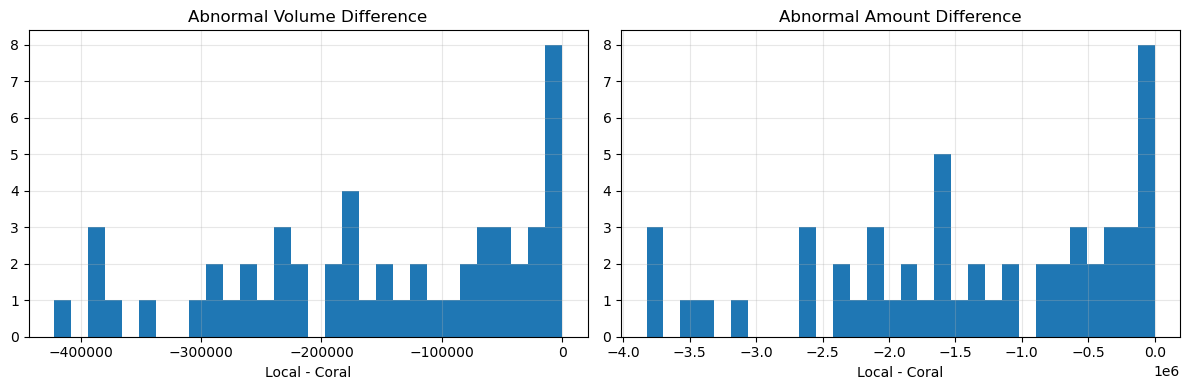

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(abnormal_minutes["volume_diff"], bins=30)
axes[0].set_title("Abnormal Volume Difference")
axes[0].set_xlabel("Local - Coral")
axes[0].grid(alpha=0.3)

axes[1].hist(abnormal_minutes["amount_diff"], bins=30)
axes[1].set_title("Abnormal Amount Difference")
axes[1].set_xlabel("Local - Coral")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
# 6 看异常样本明细
abnormal_detail = abnormal_minutes[
    [
        "date", "timestamp",
        "local_close", "coral_close", "close_diff",
        "local_volume", "coral_volume", "volume_diff", "volume_diff_pct",
        "local_amount", "coral_amount", "amount_diff", "amount_diff_pct",
        "is_close_abnormal", "is_volume_abnormal", "is_amount_abnormal"
    ]
].copy()

abnormal_detail.sort_values(
    ["date", "timestamp"]
).head(20)

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,volume_diff_pct,local_amount,coral_amount,amount_diff,amount_diff_pct,is_close_abnormal,is_volume_abnormal,is_amount_abnormal
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,-0.296073,2558422.0,3637990.0,-1079568.0,-0.296748,False,True,True
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,-1.000000,0.0,3485608.0,-3485608.0,-1.000000,True,True,True
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,-0.358449,2403498.0,3750026.0,-1346528.0,-0.359072,False,True,True
479,2026-03-12,2026-03-12 15:00:00,9.19,9.19,0.00,0.0,282000.0,-282000.0,-1.000000,0.0,2591580.0,-2591580.0,-1.000000,False,True,True
480,2026-03-13,2026-03-13 09:31:00,9.22,9.22,0.00,632048.0,684348.0,-52300.0,-0.076423,5822891.0,6301436.0,-478545.0,-0.075942,False,True,True
599,2026-03-13,2026-03-13 11:30:00,9.51,9.51,0.00,115000.0,116000.0,-1000.0,-0.008621,1093967.0,1103477.0,-9510.0,-0.008618,False,True,True
719,2026-03-13,2026-03-13 15:00:00,9.47,9.47,0.00,0.0,393300.0,-393300.0,-1.000000,0.0,3724551.0,-3724551.0,-1.000000,False,True,True
720,2026-03-16,2026-03-16 09:31:00,9.50,9.50,0.00,1467102.0,1857102.0,-390000.0,-0.210005,14027355.0,17751855.0,-3724500.0,-0.209809,False,True,True
959,2026-03-16,2026-03-16 15:00:00,9.39,9.38,0.01,0.0,256300.0,-256300.0,-1.000000,0.0,2404094.0,-2404094.0,-1.000000,False,True,True
960,2026-03-17,2026-03-17 09:31:00,9.47,9.47,0.00,926000.0,1058300.0,-132300.0,-0.125012,8752144.0,9995764.0,-1243620.0,-0.124415,False,True,True


In [105]:
# 7 检查是不是边界时间问题
def classify_time_region(ts):
    t = ts.time()
    
    if t <= pd.to_datetime("09:31:00").time():
        return "market_open_boundary"
    elif t >= pd.to_datetime("14:57:00").time():
        return "market_close_boundary"
    elif pd.to_datetime("11:30:00").time() <= t <= pd.to_datetime("13:00:00").time():
        return "lunch_break"
    else:
        return "regular_intraday"

abnormal_minutes["time_region"] = abnormal_minutes["timestamp"].apply(classify_time_region)

time_region_summary = (
    abnormal_minutes
    .groupby("time_region")
    .size()
    .reset_index(name="abnormal_count")
    .sort_values("abnormal_count", ascending=False)
)

time_region_summary

,time_region,abnormal_count
1,market_close_boundary,22
2,market_open_boundary,22
0,lunch_break,9


### Boundary Timestamp Investigation

In [106]:
# 1 先把三种boundary全部取出来
boundary_times = [
    "09:31",
    "11:30",
    "15:00"
]

boundary_df = minute_compare.copy()

boundary_df["clock_time"] = boundary_df["timestamp"].dt.strftime("%H:%M")

boundary_df = boundary_df[
    boundary_df["clock_time"].isin(boundary_times)
].copy()

print(boundary_df.shape)

boundary_df.head()

(66, 20)


,date,timestamp,local_open,local_high,local_low,local_close,local_sum_volume,local_sum_amount,local_volume,local_amount,coral_close,coral_volume,coral_amount,close_diff,close_diff_pct,volume_diff,volume_diff_pct,amount_diff,amount_diff_pct,clock_time
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,9.13,9.17,397200,3637990.0,279600.0,2558422.0,9.17,397200.0,3637990.0,0.00,0.000000,-117600.0,-0.296073,-1079568.0,-0.296748,09:31
119,2026-03-11,2026-03-11 11:30:00,9.34,9.34,9.33,9.33,25040613,232449933.0,16700.0,155867.0,9.33,16700.0,155867.0,0.00,0.000000,0.0,0.000000,0.0,0.000000,11:30
239,2026-03-11,2026-03-11 15:00:00,9.30,9.30,9.30,9.30,34725659,322599404.0,0.0,0.0,9.29,375200.0,3485608.0,0.01,0.001076,-375200.0,-1.000000,-3485608.0,-1.000000,15:00
240,2026-03-12,2026-03-12 09:31:00,9.23,9.26,9.23,9.25,404800,3750026.0,259700.0,2403498.0,9.25,404800.0,3750026.0,0.00,0.000000,-145100.0,-0.358449,-1346528.0,-0.359072,09:31
359,2026-03-12,2026-03-12 11:30:00,9.13,9.13,9.12,9.12,16840496,154945337.0,124000.0,1131424.0,9.12,124000.0,1131424.0,0.00,0.000000,0.0,0.000000,0.0,0.000000,11:30


In [107]:
# 2 看看到底是哪几个字段在差
boundary_df[
[
    "date",
    "timestamp",

    "local_close",
    "coral_close",
    "close_diff",

    "local_volume",
    "coral_volume",
    "volume_diff",

    "local_amount",
    "coral_amount",
    "amount_diff"
]
].sort_values(
["date","timestamp"]
)

,date,timestamp,local_close,coral_close,close_diff,local_volume,coral_volume,volume_diff,local_amount,coral_amount,amount_diff
0,2026-03-11,2026-03-11 09:31:00,9.17,9.17,0.00,279600.0,397200.0,-117600.0,2558422.0,3637990.0,-1079568.0
119,2026-03-11,2026-03-11 11:30:00,9.33,9.33,0.00,16700.0,16700.0,0.0,155867.0,155867.0,0.0
239,2026-03-11,2026-03-11 15:00:00,9.30,9.29,0.01,0.0,375200.0,-375200.0,0.0,3485608.0,-3485608.0
240,2026-03-12,2026-03-12 09:31:00,9.25,9.25,0.00,259700.0,404800.0,-145100.0,2403498.0,3750026.0,-1346528.0
359,2026-03-12,2026-03-12 11:30:00,9.12,9.12,0.00,124000.0,124000.0,0.0,1131424.0,1131424.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
4919,2026-04-09,2026-04-09 11:30:00,8.69,8.69,0.00,13900.0,14000.0,-100.0,120806.0,121675.0,-869.0
5039,2026-04-09,2026-04-09 15:00:00,8.68,8.67,0.01,0.0,262900.0,-262900.0,0.0,2279343.0,-2279343.0
5040,2026-04-10,2026-04-10 09:31:00,8.76,8.76,0.00,336400.0,362600.0,-26200.0,2936788.0,3164990.0,-228202.0
5159,2026-04-10,2026-04-10 11:30:00,8.84,8.84,0.00,10900.0,10900.0,0.0,96367.0,96367.0,0.0


In [108]:
# 3 每个Boundary做summary
summary_boundary = (
    boundary_df
    .groupby("clock_time")
    .agg(
        observations=("clock_time","count"),

        avg_close_diff=("close_diff","mean"),

        avg_volume_diff=("volume_diff","mean"),

        avg_amount_diff=("amount_diff","mean"),

        max_volume_diff=("volume_diff","max"),

        min_volume_diff=("volume_diff","min")
    )
)

summary_boundary

,observations,avg_close_diff,avg_volume_diff,avg_amount_diff,max_volume_diff,min_volume_diff
clock_time,,,,,,
09:31,22,0.000000,-109854.545455,-9.920160e+05,-25600.0,-390000.0
11:30,22,-0.000455,-1027.272727,-9.229409e+03,0.0,-15000.0
15:00,22,0.005909,-258658.045455,-2.316858e+06,-147600.0,-422221.0


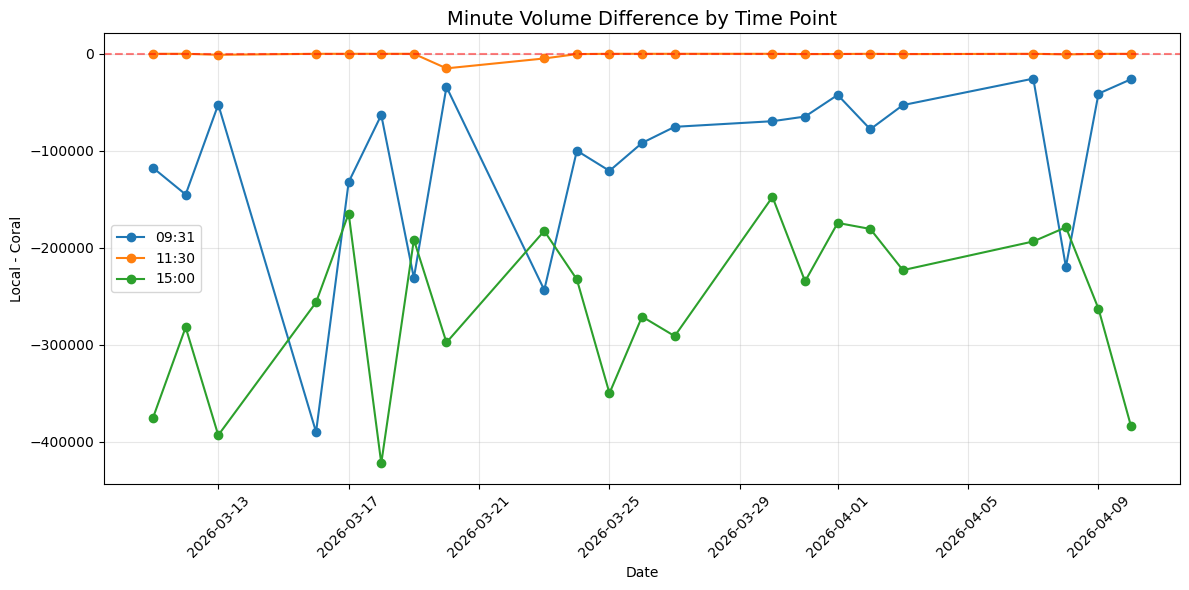

In [109]:
# 4 每一天09：31，11：30，15：00到底差多少
time_points = ["09:31", "11:30", "15:00"]

plt.figure(figsize=(12, 6))

# 为每个时间点绘制折线
for time_point in time_points:
    # 筛选数据
    time_data = boundary_df[boundary_df["clock_time"] == time_point]
    
    # 绘制折线图
    plt.plot(
        time_data["date"],
        time_data["volume_diff"],
        marker="o",
        label=f"{time_point}"
    )

# 添加参考线
plt.axhline(0, linestyle="--", color="red", alpha=0.5)

# 图表设置
plt.title("Minute Volume Difference by Time Point", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Local - Coral")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()  # 显示图例

plt.tight_layout()
plt.show()

In [110]:
# 5 Investigation
sample = boundary_df[
    boundary_df["clock_time"]=="09:31"
].iloc[0]

sample

date                2026-03-11 00:00:00
timestamp           2026-03-11 09:31:00
local_open                         9.17
local_high                         9.17
local_low                          9.13
local_close                        9.17
local_sum_volume                 397200
local_sum_amount              3637990.0
local_volume                   279600.0
local_amount                  2558422.0
coral_close                        9.17
coral_volume                   397200.0
coral_amount                  3637990.0
close_diff                          0.0
close_diff_pct                      0.0
volume_diff                   -117600.0
volume_diff_pct               -0.296073
amount_diff                  -1079568.0
amount_diff_pct               -0.296748
clock_time                        09:31
Name: 0, dtype: object

In [111]:
day = sample["date"]

tmp = qtick[
    qtick["date"]==day
].copy()

tmp["time"] = pd.to_datetime(tmp["time"])

tmp = tmp[
(tmp["time"]>=pd.to_datetime("09:29:30"))
&
(tmp["time"]<=pd.to_datetime("09:31:30"))
]

tmp[
[
"time",
"new_price",
"sum_volume",
"sum_amount"
]
]

,time,new_price,sum_volume,sum_amount


In [112]:
coral_tmp = coral_min[
coral_min["date"]==day
]

coral_tmp[
coral_tmp["timestamp"].dt.strftime("%H:%M").isin(
["09:30","09:31"]
)
]

,timestamp,date,stamp,dtype,code,name,market,sum_volume,sum_amount,status,...,min_order_volume,interest,sum_bid_volume,sum_bid_amount,sum_ask_volume,sum_ask_amount,source_file,coral_close,coral_volume,coral_amount
0,2026-03-11 09:31:00,2026-03-11,93100000,1,000009.SZ,中国宝安,2,397200,3637990.0,0,...,0,0.0,170200,1559015.0,227000,2078975.0,quota\qmin\20260311\000009.SZ.csv,9.17,397200.0,3637990.0


In [113]:
tmp = qtick[
    qtick["date"] == pd.Timestamp("2026-03-11")
].copy()

tmp = tmp.sort_values("datetime")

tmp[
    tmp["datetime"].dt.strftime("%H:%M").isin(
        ["09:30","09:31"]
    )
][
[
    "datetime",
    "sum_volume",
    "new_volume"
]
]

,datetime,sum_volume,new_volume
34,2026-03-11 09:30:00,143000,25400
35,2026-03-11 09:30:03,206100,63100
36,2026-03-11 09:30:06,230900,24800
37,2026-03-11 09:30:09,240400,9500
38,2026-03-11 09:30:12,245800,5400
39,2026-03-11 09:30:15,249700,3900
40,2026-03-11 09:30:18,260800,11100
41,2026-03-11 09:30:21,266400,5600
42,2026-03-11 09:30:24,267000,600
43,2026-03-11 09:30:27,273000,6000


In [114]:
difference_reason = pd.DataFrame({
    "time_point": ["09:31", "11:30", "15:00"],
    "main_difference": [
        "First-minute volume/amount mismatch",
        "Small morning close boundary mismatch",
        "Closing boundary volume/amount mismatch"
    ],
    "likely_reason": [
        "Opening cumulative volume treatment",
        "Morning session boundary convention",
        "Closing snapshot / last-minute aggregation convention"
    ],
    "data_quality_concern": ["Low", "Low", "Low"]
})

difference_reason

,time_point,main_difference,likely_reason,data_quality_concern
0,09:31,First-minute volume/amount mismatch,Opening cumulative volume treatment,Low
1,11:30,Small morning close boundary mismatch,Morning session boundary convention,Low
2,15:00,Closing boundary volume/amount mismatch,Closing snapshot / last-minute aggregation con...,Low


The minute-level validation demonstrates a high degree of consistency between DolphinDB (`qtick`) and CoralDB (`qmin`).

Across 5,280 matched one-minute observations:

- **Close Price:** 99.85% match rate
- **Trading Volume:** 98.48% match rate
- **Trading Amount:** 98.48% match rate

Unlike random data inconsistencies, nearly all remaining differences are concentrated at three fixed market boundary timestamps:

- **09:31** (first trading minute)
- **11:30** (morning session close)
- **15:00** (market close)

Further investigation shows that:

- Daily-level cumulative fields (`sum_volume` and `sum_amount`) are fully consistent between the two data sources.
- Close prices remain almost identical throughout the trading day.
- The remaining discrepancies are primarily caused by different **minute aggregation conventions** and **snapshot timestamp alignment**, rather than incorrect market data.

Specifically:

- At **09:31**, CoralDB records the cumulative trading activity of the opening minute, whereas the locally reconstructed minute volume is derived from cumulative differences, resulting in a smaller first-minute volume.
- At **15:00**, CoralDB includes the final trading activity in the closing minute, while the locally reconstructed series assigns zero incremental volume because no subsequent snapshot exists.
- At **11:30**, only minor differences are observed, indicating that the morning session boundary is handled consistently by both data sources.

Overall, the validation confirms that the DolphinDB `qtick` dataset is highly reliable for minute-level quantitative research. The observed discrepancies are systematic boundary effects introduced by different aggregation methodologies rather than genuine data quality issues. Therefore, `qtick` can be confidently used for downstream intraday feature engineering and quantitative analysis, provided that minute-bar construction rules are documented consistently.